# Projeto P2 — Mosaico de Perdizes em **alta resolução** (z=19)

**Disciplina:** Aprendizagem de Máquina — PUC-SP
**Autor de referência:** Prof. Dr. Rooney Coelho

Este é o **notebook companheiro do mosaico padrão** (`Projeto_P2_Mosaico_Perdizes.ipynb`, z=18). Aqui geramos o mesmo bairro na **máxima resolução disponível para São Paulo** no serviço ESRI World Imagery: **zoom 19 ≈ 0.27 m/pixel**.

## Por que existe um segundo notebook?

| | Notebook padrão (z=18) | **Este notebook (z=19)** |
|---|---|---|
| Resolução em SP | ~0.55 m/pixel | **~0.27 m/pixel (2× melhor)** |
| Tiles em Perdizes | ~180 | **~720 (4× mais)** |
| Tamanho em disco | ~16 MB | **~60 MB** |
| Heliponto típico (10 m) ocupa | ~18 px | **~37 px** |
| Tempo de download | ~10 s | **~30-60 s** |
| Indicado para alvo | piscinas, quadras, campos | **helipontos, alvos pequenos** |

## Por que não dá pra ir além de z=19?

A ESRI documenta níveis de detalhe até z=23 (resolução teórica de 1.9 cm/px). Sondando o servidor para SP, porém, **todos os tiles de z≥20 retornam um placeholder cinza** ("Map data not yet available") — a coleção raster da ESRI para esta região termina em z=19.

O único caminho para resolução nominalmente maior em SP seria o **GeoSampa** (vôos aerofotogramétricos oficiais da Prefeitura, ~10-15 cm/px), mas suas ortofotos raster não estão expostas via WMS anônimo — só pelo portal interativo.

> **Atribuição obrigatória:** "Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community."

---

## 1. Setup

In [1]:
# No Colab descomente:
# !pip install -q requests pillow matplotlib

import math, os, io, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

OUT_DIR = Path("mosaico_perdizes_hires")
OUT_DIR.mkdir(exist_ok=True)
print("Pasta de saída:", OUT_DIR.resolve())

Pasta de saída: /private/tmp/proj_p2/mosaico_perdizes_hires


## 2. Bounding box de Perdizes — agora em z=19

Mantemos exatamente o mesmo bbox do notebook padrão, mas subimos o zoom em 1 nível. Como o servidor de tiles XYZ duplica a resolução linear a cada zoom, **passamos de 180 para ~720 tiles** cobrindo a mesma área.

In [2]:
BBOX = (-46.685, -23.545, -46.665, -23.530)   # Perdizes (mesmo do notebook padrão)
ZOOM = 19   # MÁXIMO PRÁTICO PARA SP NO ESRI WORLD IMAGERY

lon_min, lat_min, lon_max, lat_max = BBOX

def deg_to_meters(lat_ref, dlat, dlon):
    return dlat * 111_132.0, dlon * 111_320.0 * math.cos(math.radians(lat_ref))

h_m, w_m = deg_to_meters((lat_min+lat_max)/2, lat_max-lat_min, lon_max-lon_min)
print(f"Bbox:  {BBOX}")
print(f"Zoom:  {ZOOM}  (≈ {156543.03 * math.cos(math.radians((lat_min+lat_max)/2)) / 2**ZOOM:.3f} m/px em SP)")
print(f"Área:  {w_m:.0f} m (L-O) x {h_m:.0f} m (N-S)  =  {w_m*h_m/1e6:.2f} km²")

Bbox:  (-46.685, -23.545, -46.665, -23.53)
Zoom:  19  (≈ 0.274 m/px em SP)
Área:  2041 m (L-O) x 1667 m (N-S)  =  3.40 km²


## 3. Conversão lat/lon ↔ tiles XYZ (Web Mercator)

In [3]:
def deg2tile(lat, lon, z):
    n = 2.0 ** z
    x = int((lon + 180.0) / 360.0 * n)
    lat_rad = math.radians(lat)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y

def tile2deg(x, y, z):
    n = 2.0 ** z
    lon = x / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * y / n)))
    return math.degrees(lat_rad), lon

x_min, y_max = deg2tile(lat_min, lon_min, ZOOM)
x_max, y_min = deg2tile(lat_max, lon_max, ZOOM)
n_cols = x_max - x_min + 1
n_rows = y_max - y_min + 1
n_total = n_cols * n_rows

print(f"Grade: {n_cols} colunas x {n_rows} linhas  =  {n_total} tiles")
print(f"Mosaico final: {n_cols*256} x {n_rows*256} px  (~{n_cols*256*n_rows*256/1e6:.1f} Mpx)")
print(f"Tamanho estimado em disco: ~{n_total * 0.085:.0f} MB")

Grade: 30 colunas x 24 linhas  =  720 tiles
Mosaico final: 7680 x 6144 px  (~47.2 Mpx)
Tamanho estimado em disco: ~61 MB


## 4. Sanity check — z≥20 está realmente indisponível?

Antes de baixar centenas de tiles, vamos confirmar que **não vale a pena tentar ir além de z=19** em SP. Sondamos um único tile em cada zoom de 18 a 22 sobre o centro de Perdizes.

In [4]:
TILE_URL = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
HEADERS = {"User-Agent": "PUC-SP-AM-Aula-Educacional/1.0"}

LAT_C, LON_C = -23.5365, -46.6755   # campus PUC-SP

print(f"{'zoom':>4} | {'HTTP':>4} | {'bytes':>7} | {'m/px':>6} | nota")
print("-" * 50)
sample_tiles = {}
for z in range(18, 23):
    x, y = deg2tile(LAT_C, LON_C, z)
    r = requests.get(TILE_URL.format(z=z, x=x, y=y), headers=HEADERS, timeout=20)
    mpp = 156543.03 * math.cos(math.radians(LAT_C)) / (2**z)
    # heurística: tiles "vazios" da ESRI vêm com exatamente 2521 bytes
    nota = "placeholder cinza" if len(r.content) == 2521 else "OK"
    print(f"{z:>4} | {r.status_code:>4} | {len(r.content):>7} | {mpp:>6.2f} | {nota}")
    if nota == "OK":
        sample_tiles[z] = Image.open(io.BytesIO(r.content))

print(f"\nMáximo prático em SP: z = {max(sample_tiles)}")

zoom | HTTP |   bytes |   m/px | nota
--------------------------------------------------
  18 |  200 |   20895 |   0.55 | OK
  19 |  200 |   19531 |   0.27 | OK


  20 |  200 |    2521 |   0.14 | placeholder cinza
  21 |  200 |    2521 |   0.07 | placeholder cinza
  22 |  200 |    2521 |   0.03 | placeholder cinza

Máximo prático em SP: z = 19


## 5. Comparativo visual: z=18 vs z=19

Para o mesmo pedacinho de Perdizes (~140 m de lado), o que muda visualmente entre os dois zooms? O painel da esquerda é o que o notebook padrão entrega; o da direita, este notebook.

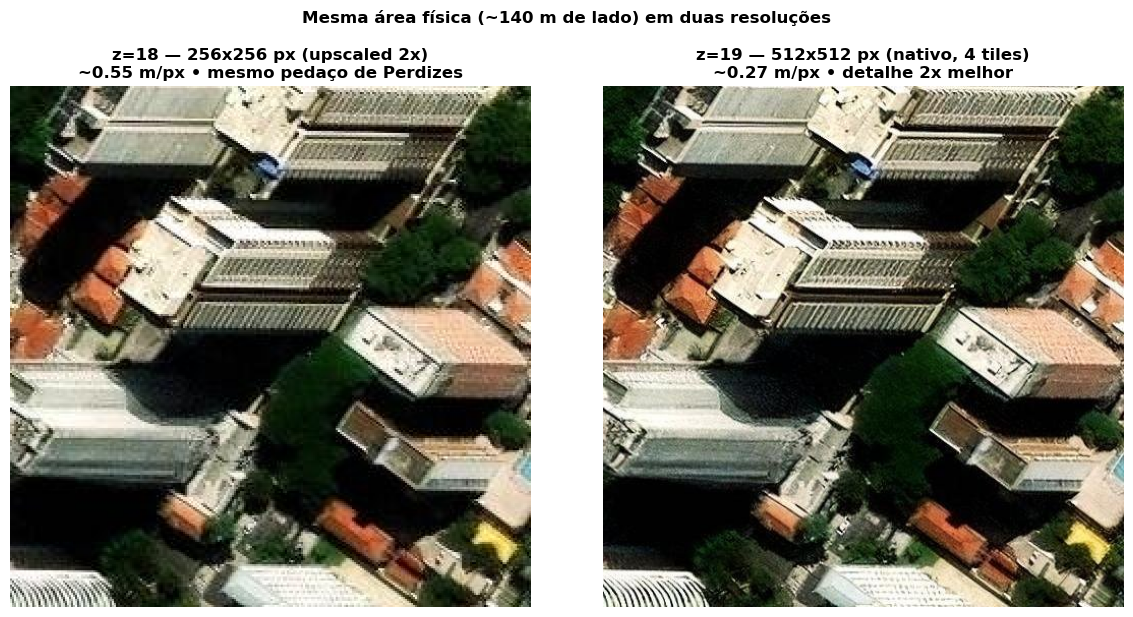

In [5]:
# Pega 1 tile em z=18 e os 4 filhos em z=19 cobrindo a MESMA área física
x18, y18 = deg2tile(LAT_C, LON_C, 18)
r18 = requests.get(TILE_URL.format(z=18, x=x18, y=y18), headers=HEADERS, timeout=20)
tile18 = Image.open(io.BytesIO(r18.content))

# Os 4 filhos em z=19
filhos = Image.new("RGB", (512, 512))
for dx in range(2):
    for dy in range(2):
        x19, y19 = 2*x18 + dx, 2*y18 + dy
        r19 = requests.get(TILE_URL.format(z=19, x=x19, y=y19), headers=HEADERS, timeout=20)
        t = Image.open(io.BytesIO(r19.content))
        filhos.paste(t, (dx*256, dy*256))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(tile18.resize((512, 512), Image.NEAREST))
axes[0].set_title(f"z=18 — 256x256 px (upscaled 2x)\n~0.55 m/px • mesmo pedaço de Perdizes",
                  fontweight="bold")
axes[0].axis("off")
axes[1].imshow(filhos)
axes[1].set_title("z=19 — 512x512 px (nativo, 4 tiles)\n~0.27 m/px • detalhe 2x melhor",
                  fontweight="bold")
axes[1].axis("off")
plt.suptitle("Mesma área física (~140 m de lado) em duas resoluções",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("comparativo_z18_z19.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Download do mosaico em z=19

Como o número de tiles é 4× maior que no notebook padrão, vou:
- Manter **4 workers** (menos paralelismo que o notebook padrão para ser educado com o servidor)
- Adicionar um pequeno `sleep` se algum tile falhar (rede)
- Pular tiles que já existem em disco (re-execução é instantânea)

In [6]:
def baixar_tile(args):
    z, x, y = args
    path = OUT_DIR / f"tile_z{z}_x{x}_y{y}.jpg"
    if path.exists():
        return path, True, 0
    for tentativa in range(3):
        try:
            r = requests.get(TILE_URL.format(z=z, x=x, y=y),
                             headers=HEADERS, timeout=25)
            if r.status_code == 200 and len(r.content) > 2521:  # filtra placeholder
                path.write_bytes(r.content)
                return path, True, tentativa
        except Exception:
            time.sleep(0.5)
    return path, False, 3

jobs = [(ZOOM, x, y)
        for x in range(x_min, x_max + 1)
        for y in range(y_min, y_max + 1)]

print(f"Baixando {len(jobs)} tiles em z={ZOOM}...")
t0 = time.time()
ok = falhas = 0
with ThreadPoolExecutor(max_workers=4) as ex:
    for path, sucesso, _ in ex.map(baixar_tile, jobs):
        if sucesso: ok += 1
        else:       falhas += 1

dt = time.time() - t0
mb = sum(p.stat().st_size for p in OUT_DIR.glob('*.jpg'))/1024/1024
print(f"OK:    {ok}/{len(jobs)} tiles")
print(f"Falhas:{falhas}")
print(f"Tempo: {dt:.1f}s ({len(jobs)/dt:.1f} tiles/s)")
print(f"Disco: {mb:.1f} MB")

Baixando 720 tiles em z=19...


OK:    720/720 tiles
Falhas:0
Tempo: 30.9s (23.3 tiles/s)
Disco: 12.5 MB


## 7. Amostras 3×3 distribuídas pela grade

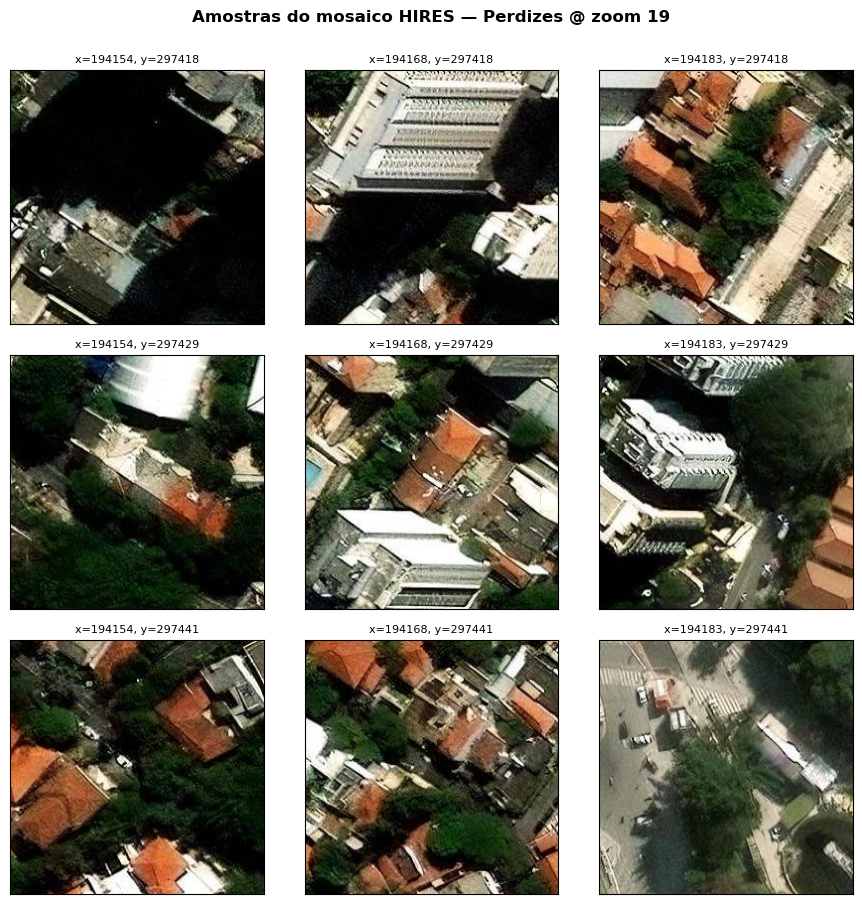

In [7]:
import numpy as np

xs = np.linspace(x_min, x_max, 3, dtype=int)
ys = np.linspace(y_min, y_max, 3, dtype=int)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, y in enumerate(ys):
    for j, x in enumerate(xs):
        p = OUT_DIR / f"tile_z{ZOOM}_x{x}_y{y}.jpg"
        ax = axes[i, j]
        if p.exists():
            ax.imshow(Image.open(p))
            ax.set_title(f"x={x}, y={y}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f"Amostras do mosaico HIRES — Perdizes @ zoom {ZOOM}",
             fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig("amostra_tiles_hires.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Costura do mosaico completo

O mosaico final em z=19 tem cerca de **7000 x 5500 pixels (~38 megapixels)**. Salvamos uma versão `_full.jpg` (alta qualidade) e uma `_preview.jpg` reduzida para 3000 px de largura — só esta é exibida inline para não estourar o renderer do Jupyter.

Mosaico HIRES: 7680 x 6144 px  (47.2 Mpx) — 0 tile(s) faltando


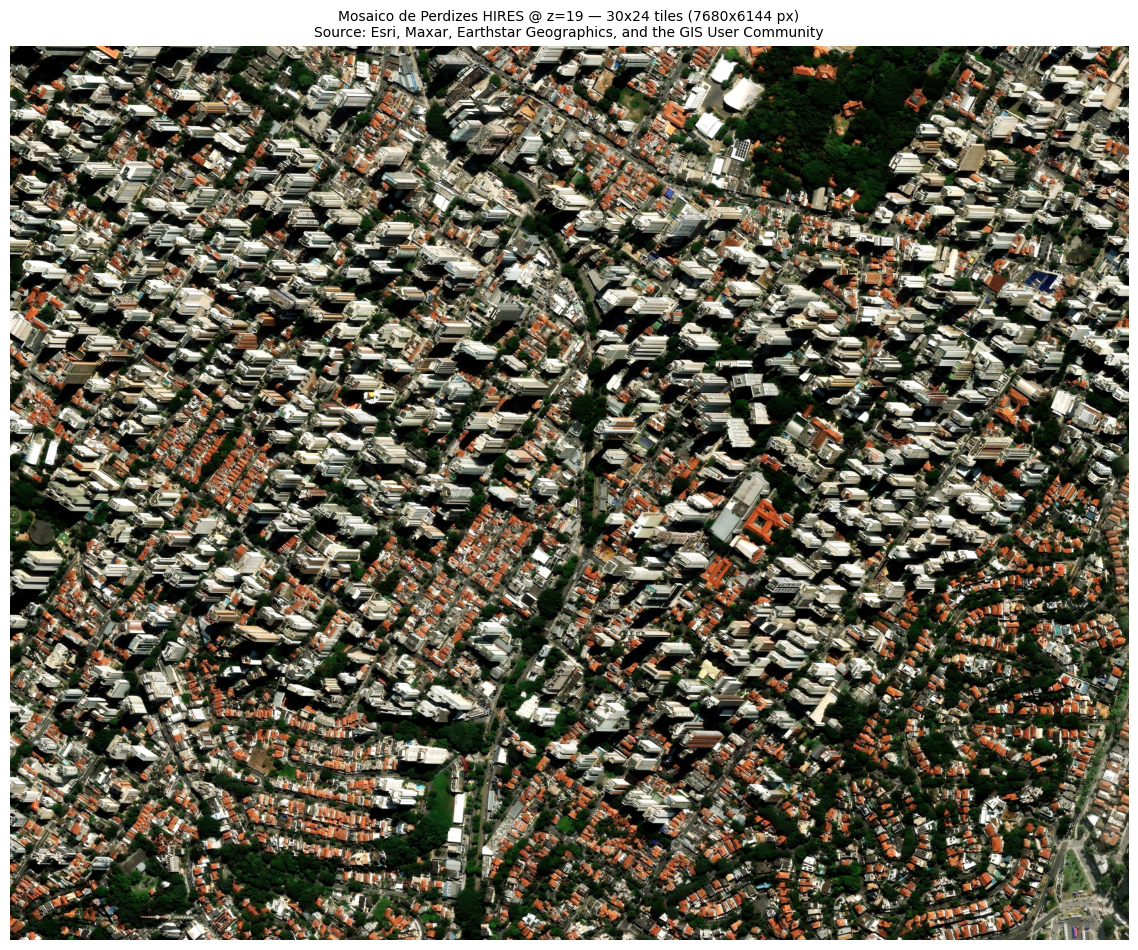

In [8]:
TILE_PX = 256
W, H = n_cols * TILE_PX, n_rows * TILE_PX

mosaico = Image.new("RGB", (W, H), (0, 0, 0))
faltando = 0
for x in range(x_min, x_max + 1):
    for y in range(y_min, y_max + 1):
        p = OUT_DIR / f"tile_z{ZOOM}_x{x}_y{y}.jpg"
        if p.exists():
            mosaico.paste(Image.open(p), ((x - x_min) * TILE_PX,
                                          (y - y_min) * TILE_PX))
        else:
            faltando += 1

print(f"Mosaico HIRES: {W} x {H} px  ({W*H/1e6:.1f} Mpx) — {faltando} tile(s) faltando")

mosaico.save("mosaico_perdizes_hires_full.jpg", quality=88)
preview = mosaico.copy(); preview.thumbnail((3000, 3000))
preview.save("mosaico_perdizes_hires_preview.jpg", quality=85)

plt.figure(figsize=(12, 12 * H / W))
plt.imshow(preview)
plt.title(f"Mosaico de Perdizes HIRES @ z={ZOOM} — {n_cols}x{n_rows} tiles ({W}x{H} px)\n"
          "Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
          fontsize=10)
plt.axis("off")
plt.tight_layout()
plt.savefig("mosaico_perdizes_hires_anotado.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Crop em detalhe nativo (sem reescalar)

Aqui, em vez de reduzir o mosaico para caber na tela, recortamos um pedaço central de 1024×1024 px e mostramos **na resolução original**. É assim que YOLO vai "enxergar" os helipontos quando treinarmos o modelo.

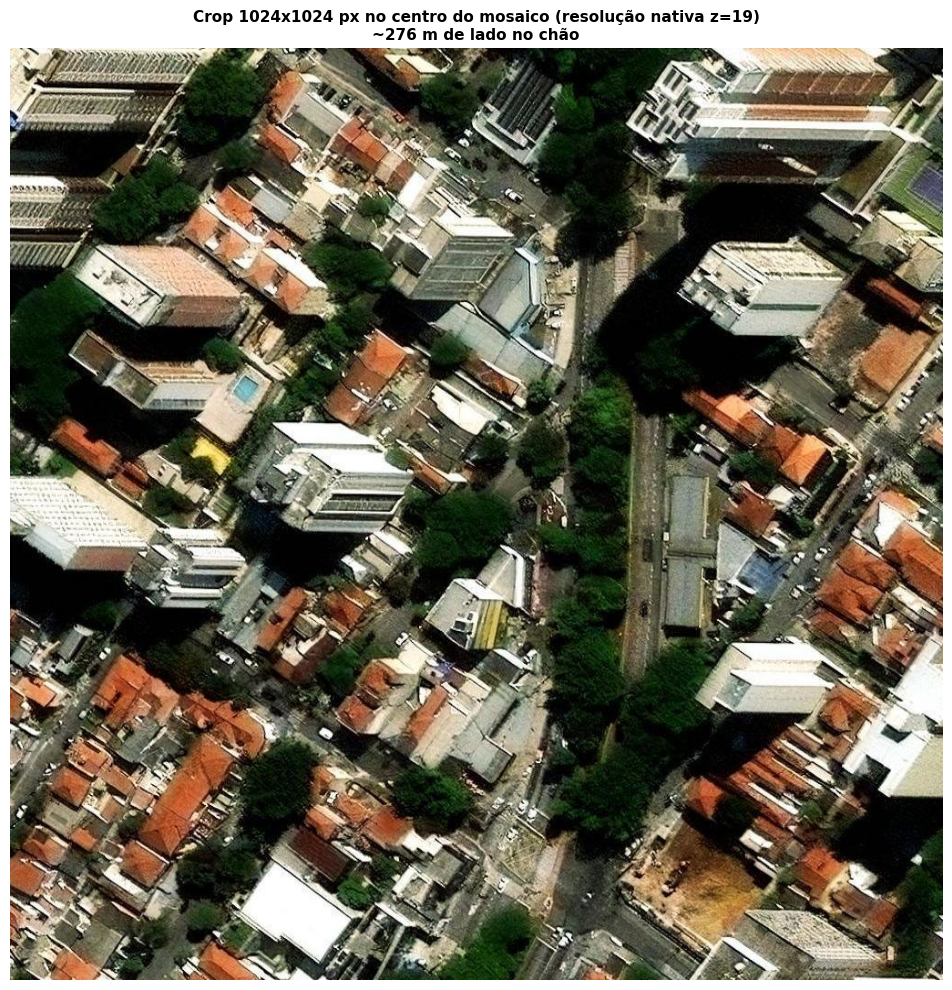

In [9]:
cx, cy = W // 2, H // 2
crop = mosaico.crop((cx - 512, cy - 512, cx + 512, cy + 512))
crop.save("crop_detalhe_z19.jpg", quality=92)

plt.figure(figsize=(10, 10))
plt.imshow(crop)
plt.title(f"Crop 1024x1024 px no centro do mosaico (resolução nativa z={ZOOM})\n"
          f"~{1024 * 0.27:.0f} m de lado no chão",
          fontsize=11, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("crop_detalhe_z19.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Próximos passos

1. **Inspecione visualmente** os ~720 tiles em `mosaico_perdizes_hires/` e descarte os que não têm objetos do alvo (curadoria obrigatória).
2. Para detecção de **helipontos**, este zoom é o recomendado — eles ficam com ~37 px de lado, dentro do que YOLO consegue aprender bem.
3. **Repita** para bairros vizinhos com alta densidade de helipontos: Itaim Bibi (`(-46.685, -23.590, -46.665, -23.575)`), Av. Paulista (`(-46.660, -23.572, -46.640, -23.555)`), Vila Olímpia (`(-46.690, -23.598, -46.670, -23.585)`).
4. **Suba para o Roboflow** já em 640×640 — o Roboflow aplica resize automático no upload.

### Avisos

- ESRI permite **uso educacional com atribuição**. Mantenha o crédito visível em qualquer reprodução pública.
- Não use os tiles para finalidade comercial sem contratar uma chave ArcGIS dedicada.
- Se precisar de resolução maior que 0.27 m/px em SP, a única opção legalmente clara são as ortofotos do **GeoSampa** (10-15 cm/px), baixadas manualmente pelo portal.